In [22]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

df = pd.read_csv("foodAllergyAnalysisZenodo.csv")
print(df.shape)
df.head()
df.info()

(333200, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333200 entries, 0 to 333199
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   SUBJECT_ID               333200 non-null  int64  
 1   BIRTH_YEAR               333200 non-null  int64  
 2   GENDER_FACTOR            333200 non-null  object 
 3   RACE_FACTOR              333200 non-null  object 
 4   ETHNICITY_FACTOR         333200 non-null  object 
 5   PAYER_FACTOR             333200 non-null  object 
 6   ATOPIC_MARCH_COHORT      333200 non-null  bool   
 7   AGE_START_YEARS          333200 non-null  float64
 8   AGE_END_YEARS            333200 non-null  float64
 9   SHELLFISH_ALG_START      5246 non-null    float64
 10  SHELLFISH_ALG_END        1051 non-null    float64
 11  FISH_ALG_START           1796 non-null    float64
 12  FISH_ALG_END             527 non-null     float64
 13  MILK_ALG_START           7289 non-null    floa

In [10]:
# convert dataset columns to 0/1 labels
df["MILK_ALLERGY"] = df["MILK_ALG_START"].notna().astype(int)

print(df["MILK_ALLERGY"].value_counts())

MILK_ALLERGY
0    325911
1      7289
Name: count, dtype: int64


In [11]:
# define features and targets
features = [
    "AGE_START_YEARS",
    "GENDER_FACTOR",
    "RACE_FACTOR",
    "ETHNICITY_FACTOR",
    "ASTHMA_START",
    "ATOPIC_DERM_START"
]

target = "MILK_ALLERGY"

In [12]:
data = df[features + [target]].copy()

data = data.dropna()
print("Clean dataset shape:", data.shape)
data = pd.get_dummies(data, drop_first=True)

Clean dataset shape: (15312, 7)


In [13]:
# train/test split
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    # for ROC-AUC we use cross-validation to get mean & std
    roc_scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    roc_mean = roc_scores.mean()
    roc_std = roc_scores.std()
    
    # train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"Mean ROC-AUC:   {roc_mean:.3f}")
    print(f"Std ROC-AUC:   {roc_std:.3f}\n")

--- Logistic Regression ---
Precision: 0.333
Recall:    0.004
F1 Score:  0.009
Mean ROC-AUC:   0.661
Std ROC-AUC:   0.021

--- Random Forest ---
Precision: 0.083
Recall:    0.004
F1 Score:  0.008
Mean ROC-AUC:   0.582
Std ROC-AUC:   0.011

--- SVM ---
Precision: 0.000
Recall:    0.000
F1 Score:  0.000
Mean ROC-AUC:   0.481
Std ROC-AUC:   0.046



c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


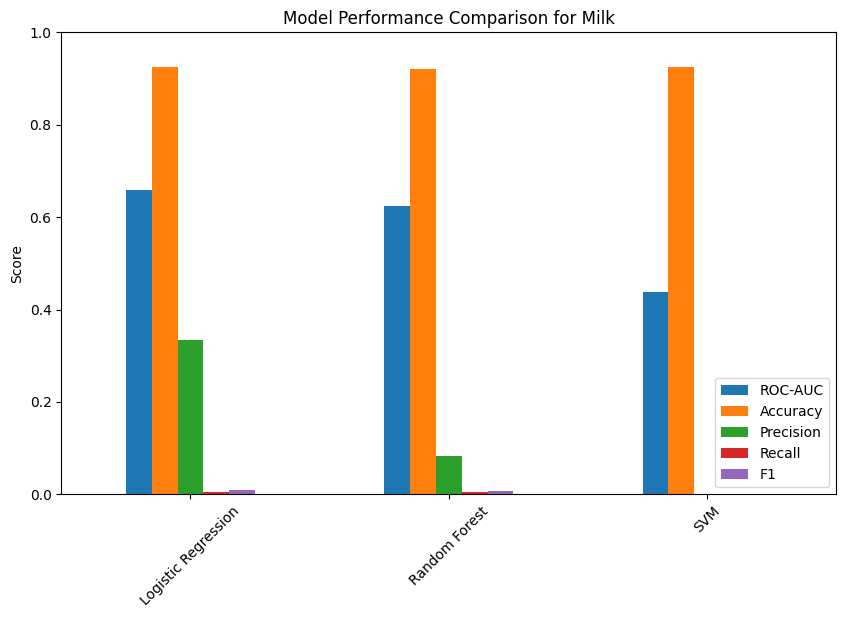

In [23]:
metrics = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability for ROC-AUC
    
    metrics[name] = {
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

# convert metrics to DataFrame for plotting
df_metrics = pd.DataFrame(metrics).T

# bar chart to compare metrics
df_metrics.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison for Milk")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

In [19]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

# prediction function
def predict_milk_allergy(age, gender, race, ethnicity, asthma, eczema):

    # create input dataframe
    input_data = pd.DataFrame({
        "AGE_START_YEARS": [age],
        "GENDER_FACTOR": [gender],
        "RACE_FACTOR": [race],
        "ETHNICITY_FACTOR": [ethnicity],
        "ASTHMA_PRESENT": [asthma],
        "ECZEMA_PRESENT": [eczema]
    })

    # encode categorical variables like training data
    input_data = pd.get_dummies(input_data)

    # make sure columns match training data
    input_data = input_data.reindex(columns=X_train.columns, fill_value=0)

    # predict probability
    probability = best_model.predict_proba(input_data)[0][1]

    return probability


factors input:
gender: 1 → Male; 2 → Female 
race: 1 → White; 2 → Black; 3 → Asian; 4 → Other
ethnicity: 1 → Non-Hispanic; 2 → Hispanic
asthma: 0 → No asthma; 1 → Asthma present
eczema: 0 → No eczema; 1 → Eczema present

In [21]:
# example
risk = predict_milk_allergy(
    age=5,
    gender=1,
    race=1,
    ethnicity=1,
    asthma=0,
    eczema=1
)

print("\nPredicted Milk Allergy Risk:", risk)


Predicted Milk Allergy Risk: 0.16002560667155977
